Precomputing directional overlaps...
Precomputation complete.
Computing observed directional differences...
Observed differences computed.
Running permutation testing...
Computing empirical p-values...


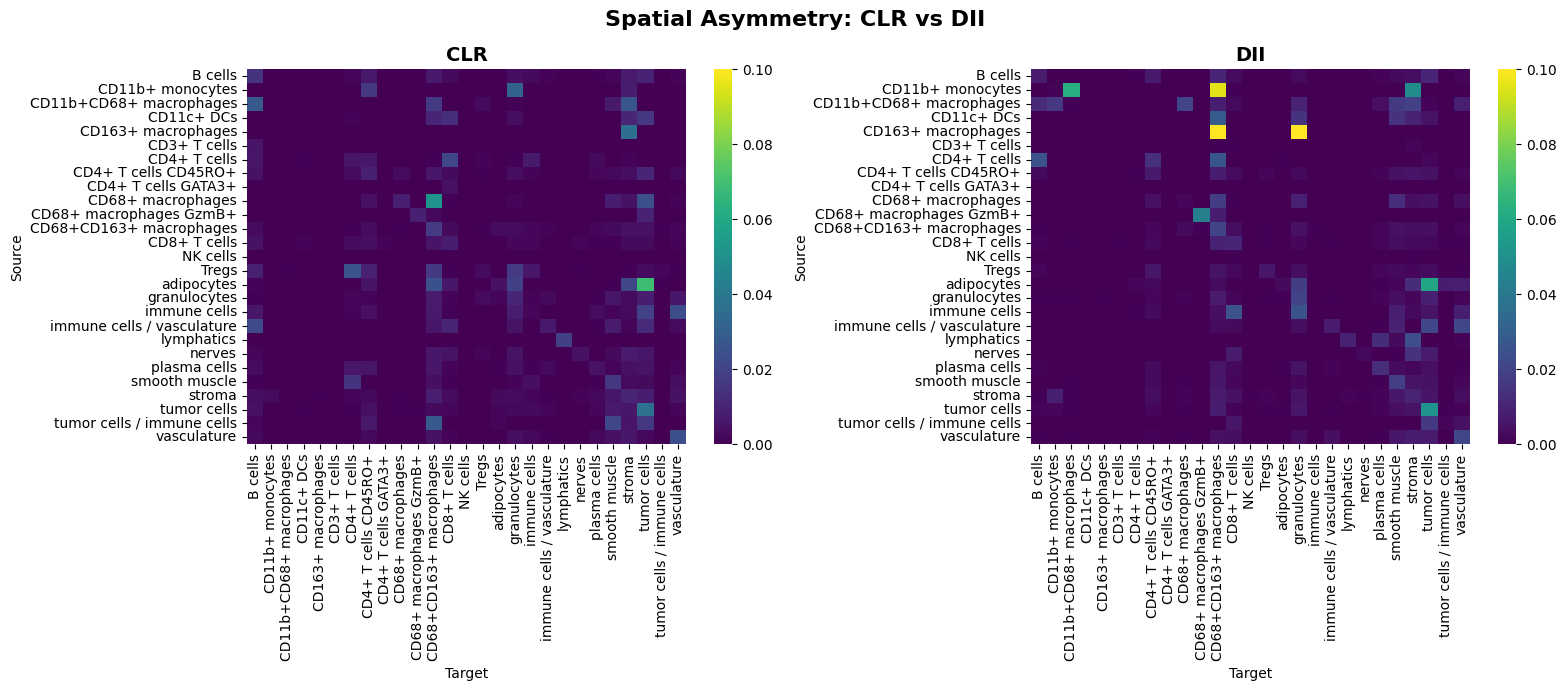

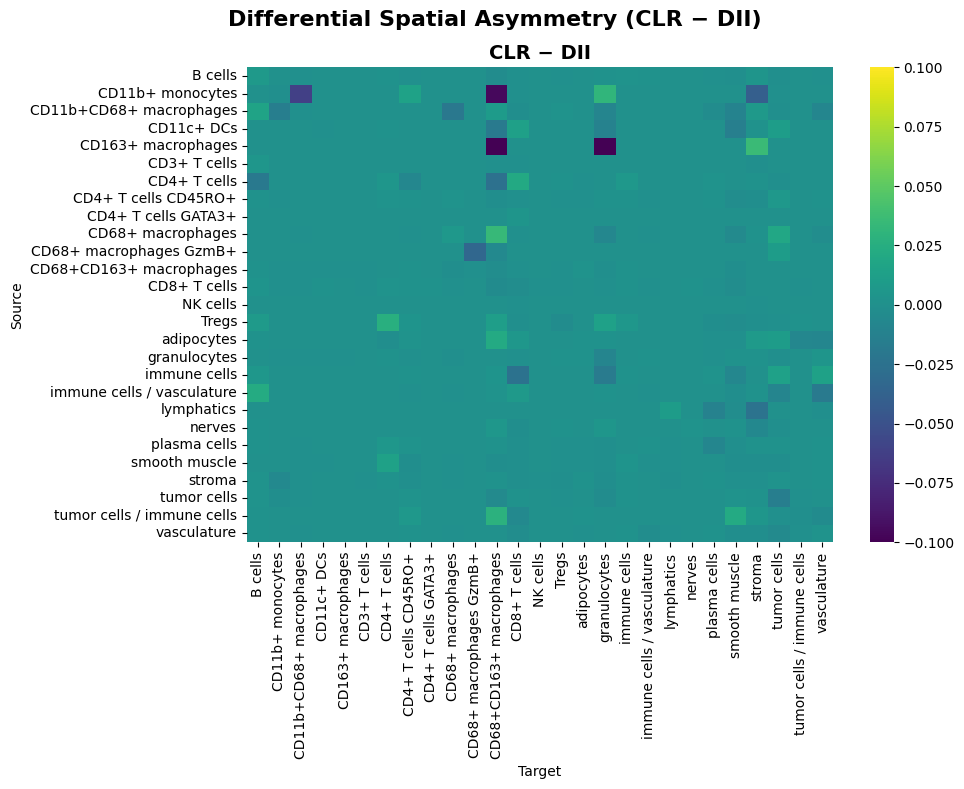

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
import os
np.random.seed(42)


# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("CRC_clusters_neighborhoods_markers.csv")
df = df[~df['ClusterName'].isin(['dirt', 'undefined'])]
df["groups"] = df["groups"].map({1: "CLR", 2: "DII"})

cell_types = df['ClusterName'].unique().tolist()
spots = df['spots'].unique()

threshold = 10
n_iterations = 1000   # You can increase safely

groups = df['groups'].unique()
assert len(groups) == 2
clr, dii = groups

# Map spot → group
spot_group_map = (
    df[['spots', 'groups']]
    .drop_duplicates()
    .set_index('spots')['groups']
    .to_dict()
)

# ==========================================================
# STEP 1: PRECOMPUTE DIRECTIONAL OVERLAP PER SPOT
# ==========================================================

print("Precomputing directional overlaps...")

spot_dir = {}   # (spot, source, target) → %

for spot in spots:

    df_spot = df[df['spots'] == spot]

    trees = {}
    counts = {}

    # Build KDTree once per cell type in this spot
    for ct in cell_types:
        coords = df_spot[df_spot['ClusterName'] == ct][['X:X', 'Y:Y']].values
        if len(coords) > 0:
            trees[ct] = KDTree(coords)
            counts[ct] = len(coords)

    # Compute directional overlap for ALL ordered pairs
    for source in cell_types:
        for target in cell_types:

            if source not in trees or target not in trees:
                continue

            if source == target:
                tree = trees[source]
                hits = tree.query_ball_tree(tree, r=threshold)
                neighbor_counts = [len(h) - 1 for h in hits]  # exclude self
                mean_neighbors = np.mean(neighbor_counts)

            else:

                tree_source = trees[source]
                tree_target = trees[target]

                hits = tree_source.query_ball_tree(tree_target, r=threshold)
                neighbor_counts = [len(h) for h in hits]
                mean_neighbors = np.mean(neighbor_counts) if len(neighbor_counts) > 0 else 0

            spot_dir[(spot, source, target)] = mean_neighbors
print("Precomputation complete.")

# ==========================================================
# STEP 2: COMPUTE OBSERVED DIRECTIONAL DIFFERENCES
# ==========================================================

print("Computing observed directional differences...")

results = []

for source in cell_types:
    for target in cell_types:

        vals_clr = []
        vals_dii = []

        for spot in spots:

            key = (spot, source, target)

            if key not in spot_dir:
                continue

            if spot_group_map[spot] == clr:
                vals_clr.append(spot_dir[key])
            else:
                vals_dii.append(spot_dir[key])

        if len(vals_clr) == 0 or len(vals_dii) == 0:
            continue

        mean_clr = np.mean(vals_clr)
        mean_dii = np.mean(vals_dii)

        diff = mean_clr - mean_dii   # Direction preserved

        results.append({
            "Source": source,
            "Target": target,
            "Mean_CLR": mean_clr,
            "Mean_DII": mean_dii,
            "Observed_Diff": diff
        })

print("Observed differences computed.")

# ==========================================================
# STEP 3: FAST PERMUTATION TESTING
# ==========================================================

print("Running permutation testing...")

def permute_once():

    shuffled_groups = np.random.permutation(list(spot_group_map.values()))
    perm_map = dict(zip(spots, shuffled_groups))

    perm_diffs = {}

    for source in cell_types:
        for target in cell_types:

            vals_clr = []
            vals_dii = []

            for spot in spots:

                key = (spot, source, target)
                if key not in spot_dir:
                    continue

                if perm_map[spot] == clr:
                    vals_clr.append(spot_dir[key])
                else:
                    vals_dii.append(spot_dir[key])

            if len(vals_clr) == 0 or len(vals_dii) == 0:
                continue

            diff = np.mean(vals_clr) - np.mean(vals_dii)
            perm_diffs[(source, target)] = diff

    return perm_diffs


null_results = Parallel(n_jobs=-1)(
    delayed(permute_once)() for _ in range(n_iterations)
)

# ==========================================================
# STEP 4: EMPIRICAL P-VALUES
# ==========================================================

print("Computing empirical p-values...")

for r in results:

    source = r["Source"]
    target = r["Target"]
    obs = r["Observed_Diff"]

    null_vals = [
        perm[(source, target)]
        for perm in null_results
        if (source, target) in perm
    ]

    if len(null_vals) == 0:
        r["Empirical_p_value"] = np.nan
        continue

    null_vals = np.array(null_vals)

    # Two-sided test
    p_val = (np.sum(np.abs(null_vals) >= abs(obs)) + 1) / (len(null_vals) + 1)
    r["Empirical_p_value"] = p_val


# ==========================================================
# STEP 5: FDR CORRECTION
# ==========================================================

results_df = pd.DataFrame(results)

# Create heatmap matrices
clr_matrix = results_df.pivot(
    index="Source",
    columns="Target",
    values="Mean_CLR"
)

dii_matrix = results_df.pivot(
    index="Source",
    columns="Target",
    values="Mean_DII"
)

diff_matrix = results_df.pivot(
    index="Source",
    columns="Target",
    values="Observed_Diff"
)

all_ct = sorted(cell_types)

clr_matrix = clr_matrix.reindex(index=all_ct, columns=all_ct)
dii_matrix = dii_matrix.reindex(index=all_ct, columns=all_ct)
diff_matrix = diff_matrix.reindex(index=all_ct, columns=all_ct)

clr_matrix = clr_matrix.fillna(0)
dii_matrix = dii_matrix.fillna(0)
diff_matrix = diff_matrix.fillna(0)

valid_mask = results_df["Empirical_p_value"].notna()

rejected, fdr_pvals, _, _ = multipletests(
    results_df.loc[valid_mask, "Empirical_p_value"],
    method='fdr_bh'
)

results_df.loc[valid_mask, "FDR_adjusted_p_value"] = fdr_pvals
results_df.loc[valid_mask, "Significant"] = np.where(rejected, "Yes", "No")

results_df.sort_values("FDR_adjusted_p_value", inplace=True)

results_df.to_csv(
    f"directional_interaction_significance_{clr}_vs_{dii}.csv",
    index=False
)

# ==========================================================
# SAVE SUPPLEMENTARY TABLES (EXCEL)
# ==========================================================

with pd.ExcelWriter("Supplementary_Table_S3_Directional_Spatial_Asymmetry.xlsx") as writer:
    results_df.to_excel(writer, sheet_name="All_Results", index=False)
    clr_matrix.to_excel(writer, sheet_name="CLR_Matrix")
    dii_matrix.to_excel(writer, sheet_name="DII_Matrix")
    diff_matrix.to_excel(writer, sheet_name="CLR_minus_DII")

# ==========================================================
# FIGURE 1: CLR vs DII (SIDE-BY-SIDE, SAVED)
# ==========================================================

vmin = min(clr_matrix.min().min(), dii_matrix.min().min())
vmax = max(clr_matrix.max().max(), dii_matrix.max().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(clr_matrix, cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[0])
axes[0].set_title("CLR", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90)

sns.heatmap(dii_matrix, cmap="viridis", vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_title("DII", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle("Spatial Asymmetry: CLR vs DII", fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig("CLR_vs_DII_heatmaps_Directional_Spatial_Asymmetry.png", dpi=600, bbox_inches='tight')
plt.show()  
plt.close()


# ==========================================================
# FIGURE 2: DIFFERENCE HEATMAP (SEPARATE PAGE)
# ==========================================================

vmax_diff = np.max(np.abs(diff_matrix.values))

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    diff_matrix,
    cmap="viridis",
    center=0,
    vmin=-vmax_diff,
    vmax=vmax_diff,
    ax=ax
)

ax.set_title("CLR − DII", fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=90)

plt.suptitle("Differential Spatial Asymmetry (CLR − DII)", fontsize=16, fontweight='bold')
plt.tight_layout()

plt.savefig("CLR_minus_DII_heatmap_Directional_Spatial_Asymmetry.png", dpi=600, bbox_inches='tight')
plt.show()  
plt.close()